# Task 2: checkpoint aggregation, analysis, and model selection

This notebook is the sole owner of final Task 2 candidate evaluation and model selection. It reads setup evidence and completed model checkpoints; worker CSV/JSON outputs are not inputs. The aim is to compare the locally trained models under one verified evaluation contract, examine where the selected model succeeds and fails, make a cautious final judgement, and export a durable selected-model package. Notebook 06 subsequently compares that fixed winner with the external SigLIP model on separate labelled Spring/Winter data. Notebook 07 then uses only the selected package for final test prediction.


## Required Structure to Run

Run Notebooks 01–04 before this notebook. The analysis requires the complete prepared-data package and all three candidate checkpoints produced from the same Notebook 01 fingerprint. Test images are not required here because final inference is owned by Notebook 07.

```text
Machine-Learning-Assignment-2/
├── pyproject.toml
├── src/
│   └── task2_utils.py
├── preprocessed_datasets/task2/
│   ├── task2_metadata.json
│   ├── task2_baseline_validation_scores.npz
│   ├── task2_deep_learning_train_images.npy
│   ├── task2_deep_learning_validation_images.npy
│   ├── task2_random_forest_train_features.npy
│   └── task2_random_forest_validation_features.npy
├── models/task2/checkpoints/
│   ├── model_random_forest.joblib
│   ├── model_random_forest_scores.npz
│   ├── model_efficientnet_b0.pt
│   └── model_densenet121.pt
```

The comparison cells verify that baseline evidence and every checkpoint share the same fingerprint, classes, labels, and validation-ID order. The notebook then creates the final comparison tables and selected-model package under `models/task2/` and diagnostic figures under `outputs/task2/`. Missing output directories are created automatically. Notebook 06 consumes the selected package and the separate labelled `ExtraSeasonData` dataset for independent Spring/Winter evaluation; Notebook 07 consumes the selected package for selected-model-only test inference.

In [1]:
%matplotlib inline
import json, shutil, sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import confusion_matrix
REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()), None)
if REPO_ROOT is None: raise FileNotFoundError('Could not find repository root')
sys.path.insert(0, str(REPO_ROOT))
from src.task2_utils import (TASK2_BASELINE_SCORES_PATH, TASK2_CHECKPOINT_DIR, TASK2_FIGURE_DIR, TASK2_MODEL_DIR,
    TASK2_OUTPUT_DIR, NeuralTrainer, build_task2_neural_model,
    ensure_task2_directories, evaluate_predictions,
    load_checkpoint_candidate, model_checkpoint_path, per_class_table,
    prepared_namespace, random_forest_paths)
ensure_task2_directories()
sns.set_theme(style='whitegrid', context='notebook')


## Load and validate checkpoint evidence

This section loads the saved baseline and model checkpoints. Before any comparison, it verifies the preprocessing fingerprint, class ordering, validation IDs and their order, validation labels, score dimensions, and finite score values. These checks prevent results produced from different splits, preprocessing configurations, or class-index mappings from being combined accidentally. A checkpoint that fails this contract is rejected rather than silently compared.


In [2]:
data = prepared_namespace()
setup = data.config
CLASSES, TARGET, FINGERPRINT = data.classes, data.target, data.fingerprint
validation_ids = data.validation_ids
def validate_arrays(label, ids, truth, scores):
    if not np.array_equal(np.asarray(ids, dtype=str), validation_ids): raise ValueError(f'{label}: validation-ID ordering mismatch')
    if not np.array_equal(np.asarray(truth, dtype=int), data.y_val): raise ValueError(f'{label}: validation truth mismatch')
    scores = np.asarray(scores)
    if scores.shape != (len(validation_ids), len(CLASSES)): raise ValueError(f'{label}: invalid score shape {scores.shape}')
    if not np.isfinite(scores).all(): raise ValueError(f'{label}: non-finite scores')
    return scores
baseline_path = TASK2_BASELINE_SCORES_PATH
if not baseline_path.exists(): raise FileNotFoundError(f'Missing {baseline_path}; rerun Notebook 01')
with np.load(baseline_path, allow_pickle=False) as saved:
    if str(saved['fingerprint'].item()) != FINGERPRINT: raise ValueError('Baseline fingerprint mismatch')
    if list(saved['classes'].astype(str)) != list(CLASSES): raise ValueError('Baseline class ordering mismatch')
    baseline_scores = validate_arrays('Baseline', saved['validation_ids'], saved['true_indices'], saved['majority_scores'])
rf_model_path, rf_scores_path = random_forest_paths()
if not (rf_model_path.exists() and rf_scores_path.exists()): raise FileNotFoundError('Missing Random Forest checkpoint pair; run Notebook 02')
with np.load(rf_scores_path, allow_pickle=False) as saved:
    if str(saved['fingerprint'].item()) != FINGERPRINT: raise ValueError('Random Forest fingerprint mismatch')
    if list(saved['classes'].astype(str)) != list(CLASSES): raise ValueError('Random Forest class ordering mismatch')
    rf_scores = validate_arrays('Random Forest', saved['validation_ids'], saved['true_indices'], saved['scores'])
    rf_config = json.loads(str(saved['model_config_json'].item()))
efficientnet_checkpoint = load_checkpoint_candidate('efficientnet_b0', fingerprint=FINGERPRINT, classes=CLASSES, validation_ids=validation_ids)
densenet_checkpoint = load_checkpoint_candidate('densenet121', fingerprint=FINGERPRINT, classes=CLASSES, validation_ids=validation_ids)
print('Validated current checkpoints for run', FINGERPRINT)


Validated current checkpoints for run 5f507c7bb57f


**Finding:** The baseline, Random Forest, EfficientNet-B0, and DenseNet-121 results all match the same data split.

## Consistent comparison and winner selection

This section compares every model on the same validation rows using Top-1 accuracy, macro-F1, balanced accuracy, weighted F1, and Top-2 accuracy. Their equal-weight mean provides a consistent composite ranking, while macro-F1 remains the primary class-balanced metric. The five values are correlated summaries of the same predictions—not five independent sources of evidence—so small score differences should not be overstated.


In [3]:
def softmax(x):
    shifted = x - x.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)
selection_metrics = ['Top-1 accuracy', 'Macro-F1', 'Balanced accuracy', 'Weighted F1', 'Top-2 accuracy']
efficientnet_record = {**efficientnet_checkpoint, 'name': 'EfficientNet-B0', 'checkpoint_role': 'primary'}
densenet_record = {**densenet_checkpoint, 'name': 'DenseNet-121', 'checkpoint_role': 'primary'}
candidates = [
    {'name': 'Baseline: majority class', 'scores': baseline_scores, 'probabilities': baseline_scores, 'kind': 'baseline'},
    {'name': 'Random Forest', 'scores': rf_scores, 'probabilities': rf_scores, 'kind': 'rf', 'model_config': rf_config, 'checkpoint_path': rf_model_path},
    {**efficientnet_record, 'probabilities': softmax(efficientnet_record['scores']), 'kind': 'neural'},
    {**densenet_record, 'probabilities': softmax(densenet_record['scores']), 'kind': 'neural'},
]
rows = [evaluate_predictions(data.y_val, item['scores'].argmax(1), item['scores'], item['name']) for item in candidates]
model_comparison = pd.DataFrame(rows)
model_comparison['Selection score'] = model_comparison[selection_metrics].mean(axis=1)
model_comparison = model_comparison.sort_values(
    ['Selection score', 'Macro-F1', 'Top-1 accuracy'], ascending=False
).reset_index(drop=True)
trained = model_comparison[model_comparison['Model'] != 'Baseline: majority class'].reset_index(drop=True)
FINAL_NAME = trained.iloc[0]['Model']
winner = next(item for item in candidates if item['name'] == FINAL_NAME)
final_scores, final_probabilities = winner['scores'], winner['probabilities']
y_true, y_pred = data.y_val, final_scores.argmax(1)
display(model_comparison)
print('Selected by equal-weight mean of', ', '.join(selection_metrics) + ':', FINAL_NAME)


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy,Selection score
0,DenseNet-121,0.756146,0.751516,0.721136,0.754391,0.934444,0.783527
1,EfficientNet-B0,0.751123,0.745440,0.710244,0.748788,0.942109,0.779541
2,Random Forest,0.667724,0.684041,0.683212,0.668561,0.929553,0.726618
3,Baseline: majority class,0.493259,0.165162,0.250000,0.325871,0.687550,0.384368


Selected by equal-weight mean of Top-1 accuracy, Macro-F1, Balanced accuracy, Weighted F1, Top-2 accuracy: DenseNet-121


**Finding.** DenseNet-121 ranks first on the selected composite measure and also obtains the highest macro-F1. Relative to EfficientNet-B0, its advantage is only 0.50 percentage points in accuracy, 0.61 points in macro-F1, and 0.40 points in composite score. The result supports selecting DenseNet for this run, but the models were not tested across repeated splits or random seeds, so it does not establish that DenseNet is universally superior.


## Selected-model diagnostics

This section examines the selected model through class-level results, a row-normalised confusion matrix, confidence calibration, training history, parameter count, and checkpoint size. Expected calibration error (ECE) is the sample-weighted absolute difference between mean confidence and observed accuracy across confidence bins; smaller values indicate closer agreement for the chosen binning scheme. ECE complements classification metrics but does not guarantee that every individual probability is reliable.


,Season,Support,Precision,Recall,F1
0,Fall,2052,0.730421,0.668129,0.697888
1,Spring,312,0.907173,0.689103,0.783242
2,Summer,3732,0.751325,0.835477,0.791170
3,Winter,1470,0.781106,0.691837,0.733766


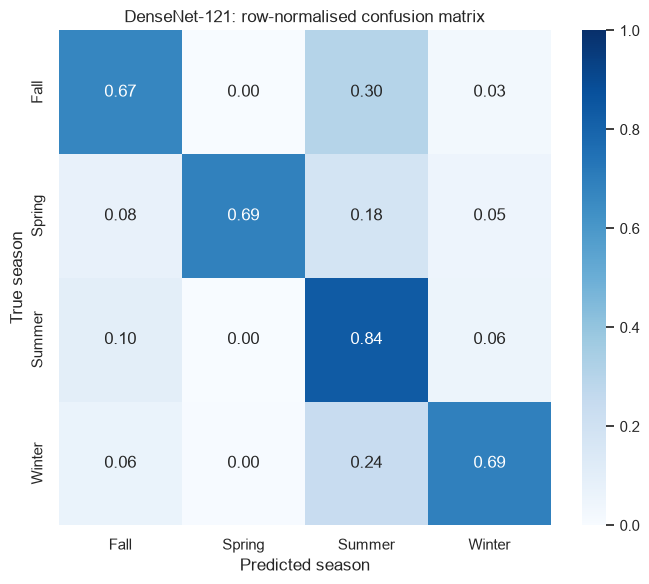

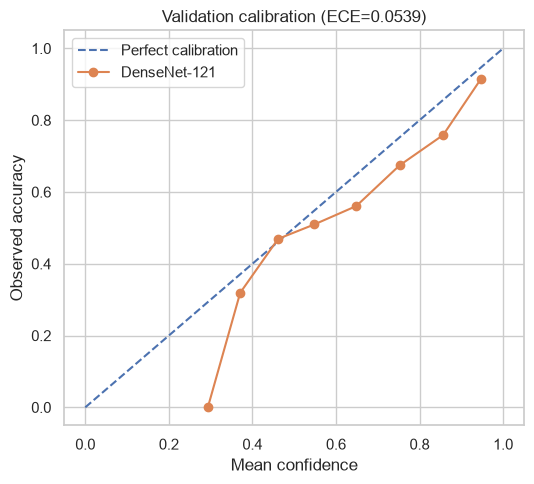

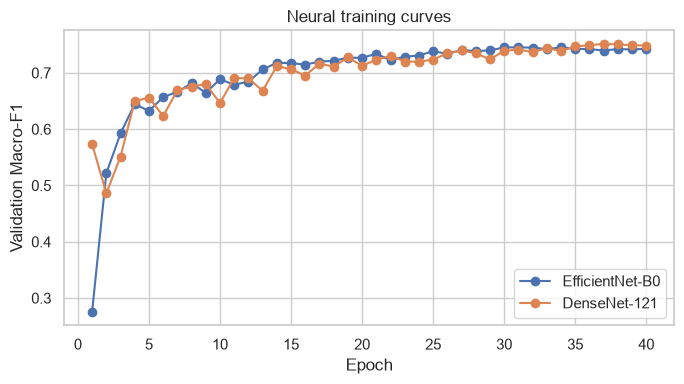

,Model,Parameters,Checkpoint size (MB)
0,Random Forest,NaN,52.328089
1,EfficientNet-B0,4012672.0,16.644477
2,DenseNet-121,6957956.0,28.717322


In [4]:
season_results = per_class_table(y_true, y_pred, CLASSES)
display(season_results)
matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASSES)), normalize='true')
plt.figure(figsize=(7, 6)); sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=1)
plt.title(f'{FINAL_NAME}: row-normalised confusion matrix'); plt.xlabel('Predicted season'); plt.ylabel('True season'); plt.tight_layout()
plt.savefig(TASK2_FIGURE_DIR / 'confusion_matrix.png', dpi=180, bbox_inches='tight'); plt.show()
def calibration(probabilities, truth, n_bins=10):
    confidence, predicted = probabilities.max(1), probabilities.argmax(1)
    rows, ece = [], 0.0
    for lower, upper in zip(np.linspace(0,1,n_bins+1)[:-1], np.linspace(0,1,n_bins+1)[1:]):
        chosen = (confidence > lower) & (confidence <= upper)
        if chosen.any():
            accuracy, mean_confidence = (predicted[chosen] == truth[chosen]).mean(), confidence[chosen].mean()
            ece += chosen.mean() * abs(accuracy - mean_confidence)
            rows.append({'confidence': mean_confidence, 'accuracy': accuracy, 'count': int(chosen.sum())})
    return ece, pd.DataFrame(rows)
ece, calibration_frame = calibration(final_probabilities, y_true)
plt.figure(figsize=(5.5,5)); plt.plot([0,1],[0,1],'--',label='Perfect calibration'); plt.plot(calibration_frame['confidence'], calibration_frame['accuracy'], marker='o', label=FINAL_NAME)
plt.xlabel('Mean confidence'); plt.ylabel('Observed accuracy'); plt.title(f'Validation calibration (ECE={ece:.4f})'); plt.legend(); plt.tight_layout()
plt.savefig(TASK2_FIGURE_DIR / 'calibration.png', dpi=180, bbox_inches='tight'); plt.show()
plt.figure(figsize=(7,4))
for label, record in [
    ('EfficientNet-B0', efficientnet_record),
    ('DenseNet-121', densenet_record),
]:
    history = pd.DataFrame(record['history']); plt.plot(history['epoch'], history['val macro-F1'], marker='o', label=label)
plt.xlabel('Epoch'); plt.ylabel('Validation Macro-F1'); plt.title('Neural training curves'); plt.legend(); plt.tight_layout()
plt.savefig(TASK2_FIGURE_DIR / 'training_curves.png', dpi=180, bbox_inches='tight'); plt.show()
efficientnet_count = build_task2_neural_model(efficientnet_record['model_config'], len(CLASSES))
densenet_count = build_task2_neural_model(densenet_record['model_config'], len(CLASSES))
parameter_counts = {
    'Random Forest': np.nan,
    'EfficientNet-B0': sum(p.numel() for p in efficientnet_count.parameters()),
    'DenseNet-121': sum(p.numel() for p in densenet_count.parameters()),
}
deployment = pd.DataFrame([{'Model': item['name'], 'Parameters': parameter_counts[item['name']], 'Checkpoint size (MB)': item['checkpoint_path'].stat().st_size/1e6} for item in candidates if item['kind'] != 'baseline'])
display(deployment)


**Diagnostic findings.** Summer is the strongest-recall class at 83.5%. The largest off-diagonal errors are 621 Fall images and 354 Winter images predicted as Summer, revealing a remaining pull toward the dominant class and suggesting that many products lack unambiguous season-specific evidence. Spring has high precision (90.7%) but lower recall (68.9%); with only 312 validation examples, that estimate is less stable than the Summer result. Fall has the lowest F1 at 0.698.

DenseNet's ECE is approximately 0.054, meaning that confidence and observed accuracy differ by about 5.4 percentage points on average under this ten-bin calculation. This is encouraging but depends on the binning scheme and should not be treated as a complete guarantee of probability reliability. DenseNet has 6.96 million parameters and a 28.7 MB checkpoint, compared with EfficientNet's 4.01 million parameters and 16.6 MB checkpoint; the performance gain therefore comes with a larger deployment footprint.


## Ultimate judgement

| Criterion | Evidence and implication |
|---|---|
| Predictive performance | DenseNet leads with 0.752 macro-F1 and a 0.784 composite score, but its margin over EfficientNet is small. |
| Minority-class behaviour | DenseNet performs credibly on Spring precision, but lower Spring recall and frequent Fall/Winter-to-Summer errors show that imbalance remains influential. |
| Generalisation gap | DenseNet's epoch-37 train-validation accuracy gap is about 9.1 points, larger than EfficientNet's 3.3-point gap, so its stronger validation score should be considered alongside greater overfitting pressure. |
| Calibration | The selected DenseNet's ten-bin ECE is about 0.054; this supports using its scores cautiously, subject to the binning limitation. |
| Model size | DenseNet uses 6.96 million parameters and a 28.7 MB checkpoint; EfficientNet is smaller at 4.01 million and 16.6 MB. The Random Forest checkpoint is largest at 52.3 MB. |
| Recorded training cost | DenseNet took about 27 minutes versus 76 minutes for EfficientNet in these hardware- and configuration-specific runs. |
| Deployment implication | DenseNet offers the best validation result for this experiment; EfficientNet offers nearly the same performance with a smaller neural checkpoint; Random Forest is operationally simpler and provides feature evidence but leaves a meaningful predictive gap. |

DenseNet-121 is selected because it provides the strongest validation macro-F1 and composite score while maintaining acceptable calibration. EfficientNet-B0 remains a credible alternative because its performance is very close and its parameter count is smaller. Random Forest is easier to inspect and can run without a neural inference stack, but its engineered representation leaves a meaningful performance gap.


## Consolidated exports and selected-model package

This section saves the comparison results, diagnostic summaries, and final selected model together with the information needed to use it later.

In [5]:
model_comparison.to_csv(TASK2_MODEL_DIR / 'task2_results.csv', index=False)
season_results.to_csv(TASK2_MODEL_DIR / 'task2_per_class_results.csv', index=False)
summary_rows = []
for record in (efficientnet_record, densenet_record):
    history = pd.DataFrame(record['history'])
    best = history.loc[history['val macro-F1'].idxmax()]
    summary_rows.append({'Model': record['name'], 'Checkpoint role': record['checkpoint_role'], 'Checkpoint file': record['checkpoint_path'].name, 'Best epoch': int(best['epoch']), 'Best Macro-F1': best['val macro-F1'], 'Training seconds': history['seconds'].sum(), 'Epochs completed': len(history)})
training_summary = pd.DataFrame(summary_rows)
training_summary.to_csv(TASK2_MODEL_DIR / 'task2_training_summary.csv', index=False)
winner_row = trained.iloc[0]
winner_metric = float(winner_row['Selection score'])
winner_validation_metrics = {metric: float(winner_row[metric]) for metric in selection_metrics}
package_metadata = {'selected_model': FINAL_NAME, 'target': TARGET, 'source_checkpoint': winner['checkpoint_path'].name, 'checkpoint_role': winner.get('checkpoint_role', 'primary'), 'fingerprint': FINGERPRINT, 'model_config': winner.get('model_config', {}), 'classes': CLASSES, 'image_target_size': setup['image_target_size'], 'normalisation_mean': setup['normalisation_mean'], 'normalisation_std': setup['normalisation_std'], 'selection_metric': 'equal_weight_mean', 'selection_metrics': selection_metrics, 'validation_value': winner_metric, 'validation_metrics': winner_validation_metrics}
if winner['kind'] == 'rf':
    selected_model_path = TASK2_MODEL_DIR / 'task2_model.joblib'
    joblib.dump({'model': joblib.load(rf_model_path), **package_metadata}, selected_model_path)
else:
    selected_model_path = TASK2_MODEL_DIR / 'task2_model.pt'
    NeuralTrainer._save({'state_dict': winner['blob']['state_dict'], **package_metadata}, selected_model_path)
print('Saved final tables, figures, and selected model:', selected_model_path)


Saved final tables, figures, and selected model: D:\RMIT\Machine Learning\Machine-Learning-Assignment-2\models\task2\task2_model.pt


**Finding:** The comparison tables, diagnostic figures, training summary, and selected DenseNet-121 model package were saved successfully.

## Limitations

- Results use one train-validation split and one random seed; no confidence intervals or repeated-run variability are available.
- Strong class imbalance makes overall accuracy optimistic and leaves minority-class estimates—especially Spring—less stable.
- Season can be a contextual merchandising label rather than a directly visible property, so some images are intrinsically ambiguous.
- Hyperparameters were selected without a documented exhaustive search, and architecture rankings may change under other configurations.
- Performance on clean catalogue images may not transfer directly to real-world photographs with clutter, different lighting, or unusual viewpoints.